In [1]:
import warnings
from time import time
from tqdm import tqdm
import psutil
import pickle
import os

import matplotlib.pylab as plt
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import torch
from transformers import AutoModelForCausalLM, pipeline
from transformers import DynamicCache, QuantizedCache
from transformers.utils.logging import disable_progress_bar
import transformers


c:\Users\a1264472\kv-compress-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
disable_progress_bar()

In [3]:
from kvpress import ExpectedAttentionPress, KnormPress

In [4]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = ".models/qwen2-0.5b"

In [5]:
os.environ["HTTP_PROXY"]  = "http://wwwinproxy.itg.ti.com:80"
os.environ["HTTPS_PROXY"] = "http://wwwinproxy.itg.ti.com:80"


In [46]:
def get_size_of_cache(outputs, cache):
    if isinstance(cache, QuantizedCache):
        # We cannot use x.element_size() * x.nelement() as below to calculate the size of the cache, 
        # as cache._quantized_value_cache[0].element_size() triggers a call of __torch_dispatch__,
        # which, in turn, unpacks the internally packed tensor; and thus does not report the correct internal storage size.
        # See also https://github.com/huggingface/optimum-quanto/blob/main/optimum/quanto/tensor/packed.py#L144

        # As QuantizedCache stores values, as well as shift and scale, 
        # we temporarily save the cache to disc and get the size of the saved object
        # temp_file = "tmp.pickle"
        # with open(temp_file, "wb") as f:
        #     pickle.dump(cache, f)
        # size_in_bytes = os.path.getsize(temp_file)
        # os.remove(temp_file)
        # return size_in_bytes
        raise NotImplementedError("Calculating the size of QuantizedCache is not implemented yet.")

    elif isinstance(cache, DynamicCache):
        size_in_bytes = 0
        

        for layer_idx, layer in enumerate(outputs.past_key_values):
            k = layer[0]
            v = layer[1]
            layer_size = k.element_size() * k.nelement() + v.element_size() * v.nelement()
            size_in_bytes += layer_size
            print(f"Layer {layer_idx}: {layer_size / 1024**2:.4f} MB")
        return size_in_bytes
    else:
        raise NotImplementedError(f"{type(cache)} is not supported yet.")

In [7]:
def _process_mem_bytes() -> int:
    return psutil.Process().memory_info().rss

In [50]:
def get_prefilling_stats_gpu(press, n_tokens, cache_implementation="dynamic"):
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    idle_peak_memory = torch.cuda.max_memory_allocated()
    
    model = AutoModelForCausalLM.from_pretrained(ckpt, dtype="auto", attn_implementation="eager").to(device)
    initial_peak_memory = torch.cuda.max_memory_allocated()
    
    # dummy inputs for prefilling
    inputs =torch.arange(n_tokens).reshape([1, n_tokens]).to(device)
    # Model warmup (for better prefilling time estimation)
    with torch.no_grad():
        model(inputs[:, :100])

    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    # run prefill pass and compute cache size and prefilling time
    with torch.no_grad(), press(model):
        if cache_implementation == "dynamic":
            cache = DynamicCache()
        elif cache_implementation == "quantized":
            cache = QuantizedCache(backend="quanto", config=model.config, nbits=4)
        else:
            raise NotImplementedError(f"Cache {cache_implementation} not yet implemented")

        start = time()
        outputs = model(inputs, num_logits_to_keep=1, past_key_values=cache)
        prefilling_time = time() - start

        cache_size = get_size_of_cache(outputs, cache)
        del cache
    # peak memory after prefilling, which includes the memory for model weights, cache, and other intermediate activations
    peak_memory = torch.cuda.max_memory_allocated()
    model.cpu()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    
    GB = 1024 ** 3
    results = {
        "Idle Peak memory": idle_peak_memory / GB,
        "Initial Peak memory": initial_peak_memory / GB,
        "Prefilling time": prefilling_time,
        "Peak memory usage": peak_memory / GB,
        "Cache Size": cache_size / GB,
        # Subtract the static model weights + KV cache to see “extra” overhead
        "Peak memory w/o weights & KV cache": (
            peak_memory - cache_size - (initial_peak_memory - idle_peak_memory)
        ) / GB,
    }

    del model
    torch.cuda.empty_cache()
    return results



def get_prefilling_stats_cpu(press, n_tokens, cache_implementation="dynamic"):
    
    idle_mem = _process_mem_bytes()
    
    model = AutoModelForCausalLM.from_pretrained(ckpt, dtype="auto", attn_implementation="eager").to(device)
    
    # memoru after model weights are loaded, but before the cache is allocated
    initial_mem = _process_mem_bytes()

    # dummy inputs for prefilling
    inputs =torch.arange(n_tokens).reshape([1, n_tokens]).to(device)
    # Model warmup (for better prefilling time estimation)
    with torch.no_grad():
        model(inputs[:, :100])

    # run prefill pass and compute cache size and prefilling time
    with torch.no_grad(), press(model):
        if cache_implementation == "dynamic":
            cache = DynamicCache()
        elif cache_implementation == "quantized":
            cache = QuantizedCache(backend="quanto", config=model.config, nbits=4)
        else:
            raise NotImplementedError(f"Cache {cache_implementation} not yet implemented")

        start = time()
        outputs = model(inputs, num_logits_to_keep=1, past_key_values=cache)
        prefilling_time = time() - start

        cache_size = get_size_of_cache(outputs, cache)
        del cache
        
    # peak memory after prefilling, which includes the memory for model weights, cache, and other intermediate activations
    peak_memory = _process_mem_bytes()

    GB = 1024 ** 3
    results = {
        "Idle Peak memory": idle_mem / GB,
        "Initial Peak memory": initial_mem / GB,
        "Prefilling time": prefilling_time, # s 
        "Peak memory usage": peak_memory / GB,
        "Cache Size": cache_size / GB,
        # Subtract the static model weights + KV cache to see “extra” overhead
        "Peak memory w/o weights & KV cache": (
            peak_memory - cache_size - (initial_mem - idle_mem)
        ) / GB,
    }

    del model
    return results

In [52]:
def get_generation_stats_gpu(press, n_tokens, max_new_tokens = 100, cache_implementation="dynamic"):
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    idle_peak_memory = torch.cuda.max_memory_allocated()
    model = AutoModelForCausalLM.from_pretrained(ckpt, dtype="auto", attn_implementation="eager").to(device)
    # disable EosTokenCriteria stopping criteria
    model.generation_config.eos_token_id = None
    model.generation_config.stop_strings = None
    
    model.generation_config.do_sample = False
    model.generation_config.temperature = None
    model.generation_config.top_p = None

    initial_peak_memory = torch.cuda.max_memory_allocated()
        
    inputs =torch.arange(n_tokens).reshape([1, n_tokens]).to(device)

    with press(model):
        kwargs = dict()
        if cache_implementation == "quantized":
            kwargs = dict(cache_implementation="quantized",
                          cache_config={"backend": "quanto", "nbits": 4})
            
        start = time()
        outputs = model.generate(inputs, max_new_tokens=max_new_tokens,
                                 generation_config=model.generation_config,
                                 pad_token_id=-1, **kwargs)
        total_time = time() - start
        assert outputs.shape == (1, n_tokens + max_new_tokens), outputs.shape

    peak_memory = torch.cuda.max_memory_allocated()

    model.cpu()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    GB = 1024 ** 3
    return {"Idle Peak memory": idle_peak_memory / GB,
            "Initial Peak memory": initial_peak_memory / GB,
            "Total time": total_time,  # s
            "Peak memory usage": peak_memory / GB
           }


def get_generation_stats_cpu(press, n_tokens, max_new_tokens = 100, cache_implementation="dynamic"):
    idle_mem = _process_mem_bytes()
    model = AutoModelForCausalLM.from_pretrained(ckpt, dtype="auto", attn_implementation="eager").to(device)
    # disable EosTokenCriteria stopping criteria
    model.generation_config.eos_token_id = None
    model.generation_config.stop_strings = None

    model.generation_config.do_sample = False
    model.generation_config.temperature = None
    model.generation_config.top_p = None

    # after loading model weights, but before generation starts
    initial_peak_memory = _process_mem_bytes()
    
    # dummy inputs for generation
    inputs =torch.arange(n_tokens).reshape([1, n_tokens]).to(device)

    with press(model):
        kwargs = dict()
        if cache_implementation == "quantized":
            kwargs = dict(cache_implementation="quantized",
                          cache_config={"backend": "quanto", "nbits": 4})
            
        start = time()
        outputs = model.generate(inputs, max_new_tokens=max_new_tokens,
                                 generation_config=model.generation_config,
                                 pad_token_id=-1, **kwargs)
        total_time = time() - start
        assert outputs.shape == (1, n_tokens + max_new_tokens), outputs.shape

    peak_memory = _process_mem_bytes()
    GB = 1024 ** 3
    return {"Idle Peak memory": idle_mem / GB,
            "Initial Peak memory": initial_peak_memory / GB,
            "Total time": total_time,  # s
            "Peak memory usage": peak_memory / GB
           }

In [10]:
def combine_stats(prefilling_stats, generation_stats):
    """Combines prefilling and generation data, then plots."""
    combined_stats = {}
    for compression_ratio in prefilling_stats:
        combined_stats[compression_ratio] = dict()
        combined_stats[compression_ratio]['Peak memory usage'] = generation_stats[compression_ratio]['Peak memory usage']
        combined_stats[compression_ratio]['Prefilling time'] = prefilling_stats[compression_ratio]['Prefilling time']
        combined_stats[compression_ratio]['Cache Size'] = prefilling_stats[compression_ratio]['Cache Size']
        combined_stats[compression_ratio]['Total time'] = generation_stats[compression_ratio]['Total time']
        combined_stats[compression_ratio]['Generation time'] = generation_stats[compression_ratio]['Total time'] - prefilling_stats[compression_ratio]['Prefilling time']
        
    return combined_stats

In [64]:
stats = {}

compression_ratios = [0.0, 0.25]
for n_tokens in [100, 300]:
    prefilling_stats = {compression_ratio : get_prefilling_stats_cpu(press=KnormPress(compression_ratio), n_tokens=n_tokens)
                        for compression_ratio in tqdm(compression_ratios)}
    generation_stats = {compression_ratio : get_generation_stats_cpu(press=KnormPress(compression_ratio), n_tokens=n_tokens)
                        for compression_ratio in tqdm(compression_ratios)}
    
    # for compression_ratio in compression_ratios:
    #     assert prefilling_stats[compression_ratio]["Idle Peak memory"] < 0.01
    #     assert generation_stats[compression_ratio]["Idle Peak memory"] < 0.01
    stats[n_tokens] = combine_stats(prefilling_stats, generation_stats)

  0%|          | 0/2 [00:00<?, ?it/s]

Layer 0: 0.0488 MB
Layer 1: 0.0488 MB
Layer 2: 0.0488 MB
Layer 3: 0.0488 MB
Layer 4: 0.0488 MB
Layer 5: 0.0488 MB
Layer 6: 0.0488 MB
Layer 7: 0.0488 MB
Layer 8: 0.0488 MB
Layer 9: 0.0488 MB
Layer 10: 0.0488 MB
Layer 11: 0.0488 MB
Layer 12: 0.0488 MB
Layer 13: 0.0488 MB
Layer 14: 0.0488 MB
Layer 15: 0.0488 MB
Layer 16: 0.0488 MB
Layer 17: 0.0488 MB
Layer 18: 0.0488 MB
Layer 19: 0.0488 MB
Layer 20: 0.0488 MB
Layer 21: 0.0488 MB
Layer 22: 0.0488 MB
Layer 23: 0.0488 MB


 50%|█████     | 1/2 [00:04<00:04,  4.76s/it]

Layer 0: 0.0366 MB
Layer 1: 0.0366 MB
Layer 2: 0.0366 MB
Layer 3: 0.0366 MB
Layer 4: 0.0366 MB
Layer 5: 0.0366 MB
Layer 6: 0.0366 MB
Layer 7: 0.0366 MB
Layer 8: 0.0366 MB
Layer 9: 0.0366 MB
Layer 10: 0.0366 MB
Layer 11: 0.0366 MB
Layer 12: 0.0366 MB
Layer 13: 0.0366 MB
Layer 14: 0.0366 MB
Layer 15: 0.0366 MB
Layer 16: 0.0366 MB
Layer 17: 0.0366 MB
Layer 18: 0.0366 MB
Layer 19: 0.0366 MB
Layer 20: 0.0366 MB
Layer 21: 0.0366 MB
Layer 22: 0.0366 MB
Layer 23: 0.0366 MB


  0%|          | 0/2 [00:00<?, ?it/s]

Layer 0: 0.1465 MB
Layer 1: 0.1465 MB
Layer 2: 0.1465 MB
Layer 3: 0.1465 MB
Layer 4: 0.1465 MB
Layer 5: 0.1465 MB
Layer 6: 0.1465 MB
Layer 7: 0.1465 MB
Layer 8: 0.1465 MB
Layer 9: 0.1465 MB
Layer 10: 0.1465 MB
Layer 11: 0.1465 MB
Layer 12: 0.1465 MB
Layer 13: 0.1465 MB
Layer 14: 0.1465 MB
Layer 15: 0.1465 MB
Layer 16: 0.1465 MB
Layer 17: 0.1465 MB
Layer 18: 0.1465 MB
Layer 19: 0.1465 MB
Layer 20: 0.1465 MB
Layer 21: 0.1465 MB
Layer 22: 0.1465 MB
Layer 23: 0.1465 MB


 50%|█████     | 1/2 [00:08<00:08,  8.86s/it]

Layer 0: 0.1099 MB
Layer 1: 0.1099 MB
Layer 2: 0.1099 MB
Layer 3: 0.1099 MB
Layer 4: 0.1099 MB
Layer 5: 0.1099 MB
Layer 6: 0.1099 MB
Layer 7: 0.1099 MB
Layer 8: 0.1099 MB
Layer 9: 0.1099 MB
Layer 10: 0.1099 MB
Layer 11: 0.1099 MB
Layer 12: 0.1099 MB
Layer 13: 0.1099 MB
Layer 14: 0.1099 MB
Layer 15: 0.1099 MB
Layer 16: 0.1099 MB
Layer 17: 0.1099 MB
Layer 18: 0.1099 MB
Layer 19: 0.1099 MB
Layer 20: 0.1099 MB
Layer 21: 0.1099 MB
Layer 22: 0.1099 MB
Layer 23: 0.1099 MB


100%|██████████| 2/2 [00:38<00:00, 19.16s/it]


In [65]:
stats

{100: {0.0: {'Peak memory usage': 1.5071678161621094,
   'Prefilling time': 2.254875898361206,
   'Cache Size': 0.0011444091796875,
   'Total time': 15.244717121124268,
   'Generation time': 12.989841222763062},
  0.25: {'Peak memory usage': 1.5076446533203125,
   'Prefilling time': 2.1426591873168945,
   'Cache Size': 0.000858306884765625,
   'Total time': 14.431618690490723,
   'Generation time': 12.288959503173828}},
 300: {0.0: {'Peak memory usage': 1.5261650085449219,
   'Prefilling time': 5.928551197052002,
   'Cache Size': 0.0034332275390625,
   'Total time': 20.13625407218933,
   'Generation time': 14.207702875137329},
  0.25: {'Peak memory usage': 1.53680419921875,
   'Prefilling time': 6.199477672576904,
   'Cache Size': 0.002574920654296875,
   'Total time': 17.386138916015625,
   'Generation time': 11.18666124343872}}}

In [66]:
def plot_compression_stats(stats, title_suffix='', max_peak_memory=6, max_cache_size=0.4, max_generation_time=25):
    gree_color = np.array([118, 185, 0]) / 255
    cmap = LinearSegmentedColormap.from_list("apple_green_to_black", [gree_color / 4, gree_color])
    
    context_lengths = sorted(stats.keys())
    compression_ratios = sorted(stats[context_lengths[0]].keys())
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    # Peak Memory Usage
    for i, context_length in enumerate(context_lengths):
        memory_usages = [stats[context_length][ratio]['Peak memory usage'] for ratio in compression_ratios]
        axes[0].plot(compression_ratios, memory_usages, '-o', label=f'{context_length} tokens', color=cmap(i/(len(context_lengths)-1)))
    
    axes[0].set_xlabel('Compression Ratio')
    axes[0].set_ylabel('Peak Memory Usage (GB)')
    axes[0].set_title('Peak Memory Usage vs. Compression Ratio' + title_suffix)
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_ylim(0, max_peak_memory)

    # Cache Size (converted to MB)
    for i, context_length in enumerate(context_lengths):
        cache_sizes = [stats[context_length][ratio]['Cache Size'] * 1024 for ratio in compression_ratios]
        axes[1].plot(compression_ratios, cache_sizes, '-o', label=f'{context_length} tokens', color=cmap(i/(len(context_lengths)-1)))
    
    axes[1].set_xlabel('Compression Ratio')
    axes[1].set_ylabel('Cache Size (MB)')
    axes[1].set_title('Cache Size vs. Compression Ratio' + title_suffix)
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_ylim(0, max_cache_size)
    
    # Generation Time
    for i, context_length in enumerate(context_lengths):
        generation_times = [stats[context_length][ratio]['Generation time'] for ratio in compression_ratios]
        axes[2].plot(compression_ratios, generation_times, '-o', label=f'{context_length} tokens', color=cmap(i/(len(context_lengths)-1)))
    
    axes[2].set_xlabel('Compression Ratio')
    axes[2].set_ylabel('Generation Time (seconds)')
    axes[2].set_title('Generation Time vs. Compression Ratio' + title_suffix)
    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_ylim(0, max_generation_time)

    plt.tight_layout()
    plt.show()

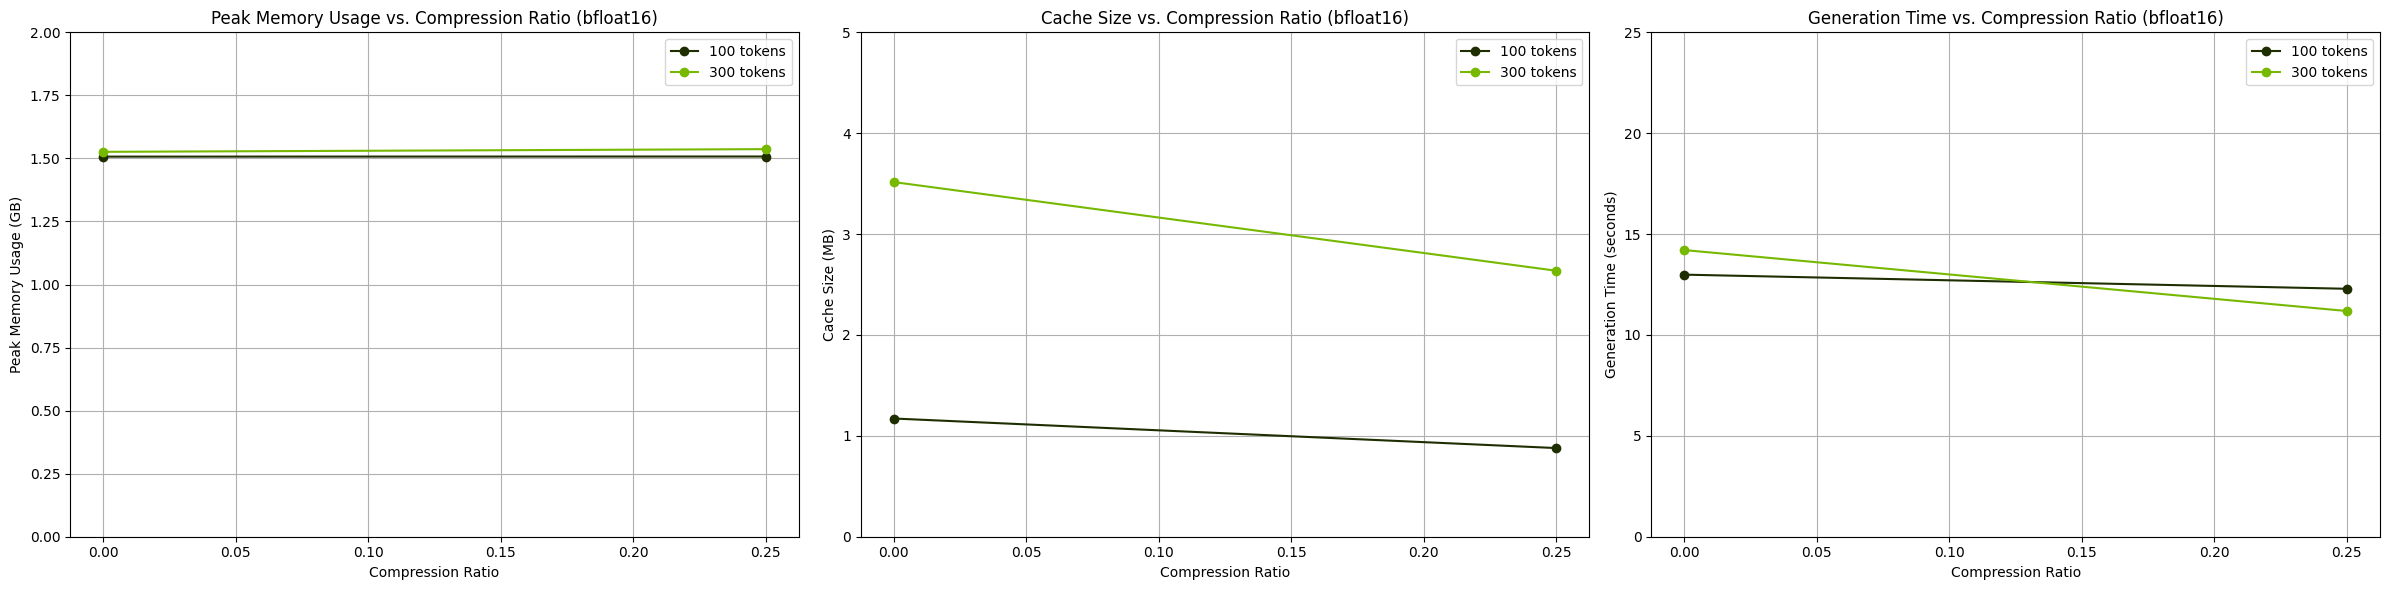

In [68]:
plot_compression_stats(stats, title_suffix=' (bfloat16)', max_peak_memory=2, max_cache_size=5)


In [3]:
import pandas as pd
import io

CSV_path = "../llamacpp_baseline_results/pg_latency_vs_ctx.csv"

df = pd.read_csv(CSV_path)

# Convert avg_ts (tokens/sec) to latency in ms/token
df["latency_ms"] = 1000.0 / df["avg_ts"]

# Classify each row by test type
def classify(row):
    if row["n_prompt"] > 0 and row["n_gen"] == 0:
        return "prefill"
    elif row["n_prompt"] == 0 and row["n_gen"] > 0:
        return "decode"
    elif row["n_prompt"] > 0 and row["n_gen"] > 0:
        return "prefill+decode"
    else:
        return "unknown"

df["test_type"] = df.apply(classify, axis=1)

# KV cache type label (use type_k; type_k == type_v in all rows)
df["kv_type"] = df["type_k"]

# Compute mean latency stats grouped by kv_type and test_type
stats = (
    df.groupby(["kv_type", "test_type"])["latency_ms"]
    .agg(
        mean_latency_ms="mean",
        std_latency_ms="std",
        min_latency_ms="min",
        max_latency_ms="max",
        n_samples="count",
    )
    .round(4)
    .reset_index()
)

# Pivot for a clean summary table
pivot = stats.pivot(index="kv_type", columns="test_type", values="mean_latency_ms")
pivot.columns.name = None
pivot = pivot.rename(columns={
    "prefill":        "mean_prefill_ms",
    "decode":         "mean_decode_ms",
    "prefill+decode": "mean_prefill+decode_ms",
})

# Speedup relative to f16 for each column
for col in pivot.columns:
    ref = pivot.loc["f16", col]
    pivot[col.replace("mean_", "speedup_")] = (ref / pivot[col]).round(4)

print("=== Mean latency (ms/token) per KV type and test mode ===")
print(pivot.to_string())

print("\n=== Full stats breakdown ===")
print(stats.to_string(index=False))

=== Mean latency (ms/token) per KV type and test mode ===
         mean_decode_ms  mean_prefill_ms  mean_prefill+decode_ms  speedup_decode_ms  speedup_prefill_ms  speedup_prefill+decode_ms
kv_type                                                                                                                           
f16             34.9734           1.3637                  8.2397             1.0000              1.0000                     1.0000
q4_0            35.4664           2.5023                  9.4471             0.9861              0.5450                     0.8722
q8_0            35.5595           1.9975                  8.9077             0.9835              0.6827                     0.9250

=== Full stats breakdown ===
kv_type      test_type  mean_latency_ms  std_latency_ms  min_latency_ms  max_latency_ms  n_samples
    f16         decode          34.9734          0.3830         34.5784         35.7848          9
    f16        prefill           1.3637          0.0343    